In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
complaints = pd.read_csv("../data/raw/complaints.csv")

In [3]:
complaints.shape

(2310, 10)

In [4]:
complaints.head()

,complaint_id,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,product_category
0,10001645,2023-06-12,Ally Savings,NaN,Unauthorized access,Security breach,Synchrony charged me a $50 monthly maintenance...,Synchrony,CT,Savings Account
1,10000510,2024-01-10,Chase Sapphire,NaN,Rewards not credited,Sign-up bonus not received,Someone made 6 fraudulent purchases on my Chas...,American Express,UT,Credit Card
2,10001411,2024-12-07,Chase Savings,NaN,Unauthorized access,Security breach,Ally Bank charged me a $100 monthly maintenanc...,Ally Bank,MD,Savings Account
3,10000045,2025-09-13,Capital One Venture,NaN,Credit limit reduction,Reduced without notice,The rewards program on my Capital One Venture ...,Capital One,MA,Credit Card
4,10001585,2023-09-26,Ally Savings,NaN,Account frozen,Frozen without warning,Synchrony closed my Ally Savings account witho...,Synchrony,CO,Savings Account


In [5]:
complaints.columns

Index(['complaint_id', 'date_received', 'product', 'sub_product', 'issue',
       'sub_issue', 'consumer_complaint_narrative', 'company', 'state',
       'product_category'],
      dtype='object')

In [6]:
complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   complaint_id                  2310 non-null   int64  
 1   date_received                 2310 non-null   object 
 2   product                       2310 non-null   object 
 3   sub_product                   0 non-null      float64
 4   issue                         2310 non-null   object 
 5   sub_issue                     2100 non-null   object 
 6   consumer_complaint_narrative  2100 non-null   object 
 7   company                       2310 non-null   object 
 8   state                         2310 non-null   object 
 9   product_category              2310 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 180.6+ KB


In [7]:
complaints.isnull().sum()

complaint_id                       0
date_received                      0
product                            0
sub_product                     2310
issue                              0
sub_issue                        210
consumer_complaint_narrative     210
company                            0
state                              0
product_category                   0
dtype: int64

In [8]:
complaints.duplicated().sum()

np.int64(0)

In [9]:
complaints["product_category"].value_counts()

product_category
Credit Card        880
Savings Account    660
Money Transfer     440
Personal Loan      330
Name: count, dtype: int64

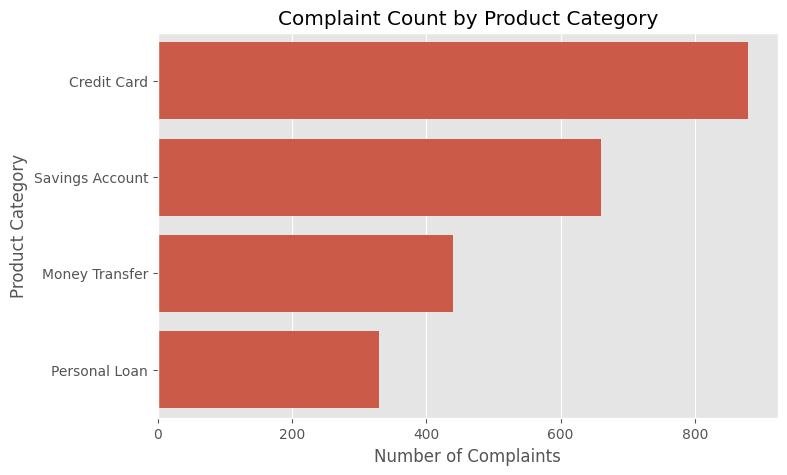

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=complaints,
    y="product_category",
    order=complaints["product_category"].value_counts().index
)

plt.title("Complaint Count by Product Category")
plt.xlabel("Number of Complaints")
plt.ylabel("Product Category")

plt.show()

In [11]:
complaints["word_count"] = complaints[
    "consumer_complaint_narrative"
].str.split().str.len()

In [12]:
complaints["word_count"].describe()

count    2100.000000
mean       58.631905
std         4.247605
min        50.000000
25%        56.000000
50%        58.000000
75%        61.000000
max        68.000000
Name: word_count, dtype: float64

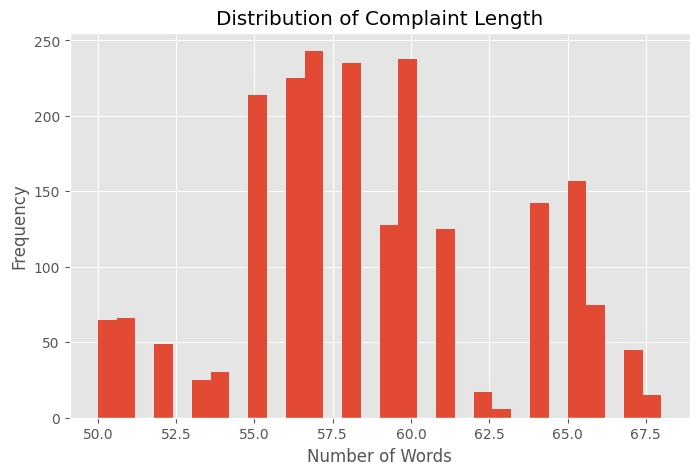

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    complaints["word_count"],
    bins=30
)

plt.title("Distribution of Complaint Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [14]:
complaints["consumer_complaint_narrative"].isna().value_counts()

consumer_complaint_narrative
False    2100
True      210
Name: count, dtype: int64

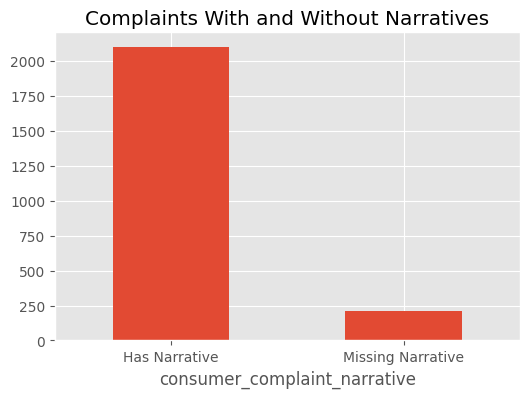

In [15]:
plt.figure(figsize=(6,4))

complaints["consumer_complaint_narrative"].isna()\
.value_counts()\
.plot(kind="bar")

plt.title("Complaints With and Without Narratives")

plt.xticks(
    [0,1],
    ["Has Narrative","Missing Narrative"],
    rotation=0
)

plt.show()

In [16]:
target_products = [
    "Credit Card",
    "Personal Loan",
    "Savings Account",
    "Money Transfer"
]

filtered_df = complaints[
    complaints["product_category"].isin(target_products)
].copy()

filtered_df.shape

(2310, 11)

In [17]:
filtered_df = filtered_df.dropna(
    subset=["consumer_complaint_narrative"]
)

filtered_df.shape

(2100, 11)

In [18]:
import re

In [19]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [20]:
filtered_df["cleaned_text"] = filtered_df[
    "consumer_complaint_narrative"
].apply(clean_text)

filtered_df[
    [
        "consumer_complaint_narrative",
        "cleaned_text"
    ]
].head()

,consumer_complaint_narrative,cleaned_text
0,Synchrony charged me a $50 monthly maintenance...,synchrony charged me a monthly maintenance fee...
1,Someone made 6 fraudulent purchases on my Chas...,someone made fraudulent purchases on my chase ...
2,Ally Bank charged me a $100 monthly maintenanc...,ally bank charged me a monthly maintenance fee...
3,The rewards program on my Capital One Venture ...,the rewards program on my capital one venture ...
4,Synchrony closed my Ally Savings account witho...,synchrony closed my ally savings account witho...


In [21]:
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [22]:
import pandas as pd

processed_df = pd.read_csv(
    "../data/processed/filtered_complaints.csv"
)

processed_df.shape

(2100, 12)

In [23]:
sample_df = filtered_df.copy()

sample_df.shape

(2100, 12)

In [24]:
sample_df["product_category"].value_counts()

product_category
Credit Card        800
Savings Account    600
Money Transfer     400
Personal Loan      300
Name: count, dtype: int64